# Fast approximation of a cylinder magnet's B-field

**Goal:** a magnet is a 6mm-diameter x 6mm-tall cylinder, magnetized along its
axis. We want a *fast* (non-magpylib-call) approximation of its B-field over
a rectangular region below it, good enough for quick repeated evaluation.

**Region of interest:** originally a 10x10x10mm cube with its top face
centered on the magnet's bottom face. We found that the field very close to
the magnet's circular edge (radius 3mm, right at the top face) is a real
physical singularity that breaks a single smooth polynomial fit. So here we
**crop the top 2mm off the box**, leaving a 10 (x) x 10 (y) x 8 (z) mm region
that starts 2mm below the magnet face. This keeps us clear of the edge
singularity and (as shown below) makes the fit dramatically more accurate.

**Approach:** since the magnet is axisymmetric, the field has no
phi-dependence and no B_phi component. We exploit this by fitting an
**axisymmetric harmonic polynomial** (regular solid harmonics in cylindrical
coordinates) rather than a generic 3D Taylor series -- fewer coefficients,
and it automatically satisfies Maxwell's equations (div B = 0, curl B = 0)
in the source-free region.


In [1]:
import time
import numpy as np
import scipy
import sympy as sp
import matplotlib.pyplot as plt
import magpylib as magpy

np.set_printoptions(suppress=True)


In [2]:
a = np.random.random((3, 3)).astype(np.float32) * 500
def hex_array_2d(arr):
    lines = []
    for row in arr:
        row_string = ", ".join(
            x.hex() +"f" for x in row.tolist()
        )
        lines.append(f"Vec3{{{row_string}}}")
    return "{\n" + ",\n".join(lines) + "\n}"

print(hex_array_2d(a))

{
Vec3{0x1.56a38e0000000p+7f, 0x1.b954800000000p+8f, 0x1.1ca27a0000000p+8f},
Vec3{0x1.310f640000000p+8f, 0x1.4dc1c80000000p+8f, 0x1.2ce1de0000000p+8f},
Vec3{0x1.eed8200000000p+8f, 0x1.8ef1020000000p+8f, 0x1.edce260000000p+7f}
}


In [3]:
a = np.random.random((3, 3)).astype(np.float32) * 500

string = "{\n"
for row in a:
    string += "{"
    for x in row:
        string += float(x).hex() + "f"
    string += "},\n"
string += "}"
print(string)

{
{0x1.ec2f8e0000000p+8f0x1.eb26d80000000p+8f0x1.50825c0000000p+7f},
{0x1.8c93780000000p+8f0x1.ddcb5c0000000p+8f0x1.9fd2300000000p+8f},
{0x1.ebe4600000000p+7f0x1.ef9ce00000000p+8f0x1.a956da0000000p+8f},
}


## 1. Define the magnet and the region of interest

Units throughout: millimeters for length, millitesla (mT) for field.

**Unit note (magpylib v5):** use `polarization` (mT, = remanence field Br) for
magnet strength, not `magnetization` -- that kwarg expects A/m and silently
gives a field ~1000x too weak if handed mT.


In [4]:
# --- Magnet: 6mm diameter x 6mm height cylinder, magnetized along +z ---
magnet = magpy.magnet.Cylinder(
    polarization=(0, 0, -600),   # mT (~N42 neodymium remanence). Adjust to your magnet's Br.
    dimension=(6, 6),            # (diameter, height) mm
    position=(0, 0, 3),          # center at z=3 -> bottom face sits at z=0
)

# --- Region of interest: 10x10x8mm box, cropped 2mm off the top ---
# Original cube: x,y in [-5,5], z in [-10,0] (top face touching magnet's bottom face)
# Cropped box:   x,y in [-5,5], z in [-10,-2]  (removes the 2mm layer nearest the magnet)
X_MIN, X_MAX = -5.0, 5.0
Y_MIN, Y_MAX = -5.0, 5.0
Z_TOP, Z_BOT = -2.0, -10.0   # top face now 2mm below the magnet, not touching it

Z_CENTER = (Z_TOP + Z_BOT) / 2.0   # -6.0mm; on-axis, so this is our expansion point
print(f"Box: x,y in [{X_MIN},{X_MAX}], z in [{Z_BOT},{Z_TOP}]  (center at z={Z_CENTER})")


Box: x,y in [-5.0,5.0], z in [-10.0,-2.0]  (center at z=-6.0)


## 2. Compute & visualize the true field (magpylib) over the box

Quick sanity-check plots so we can see what we're approximating.


In [5]:
# Cross-section (x-z plane at y=0), covering a bit above the box top too
nx, nz = 1200, 1200
x_line = np.linspace(-5, 5, nx)
z_line = np.linspace(-10, 2, nz)   # small margin above to show the magnet & cropped-out layer

Xs, Zs = np.meshgrid(x_line, z_line)
pts = np.stack([Xs.ravel(), np.zeros_like(Xs.ravel()), Zs.ravel()], axis=-1)

B = magnet.getB(pts).reshape(nx, nz, 3)

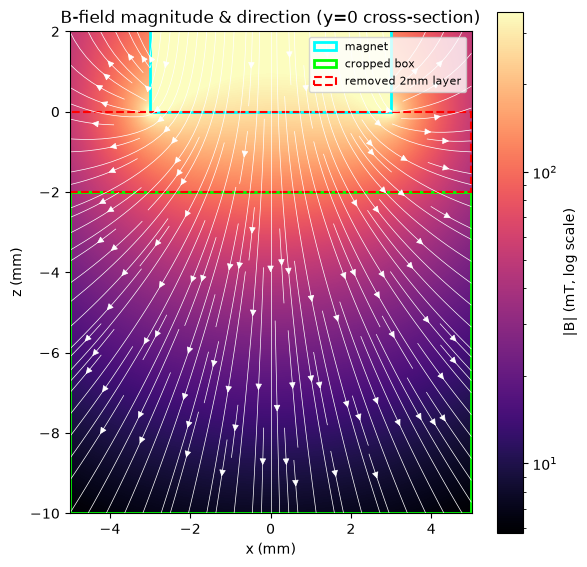

In [6]:

Bx, Bz = B[..., 0], B[..., 2]
Bmag = np.linalg.norm(B, axis=-1)

fig, ax = plt.subplots(figsize=(6, 6))
pcm = ax.pcolormesh(Xs, Zs, Bmag, shading="auto", cmap="magma",
                     norm=plt.matplotlib.colors.LogNorm(vmin=max(Bmag.min(), 1e-2), vmax=Bmag.max()/2))
fig.colorbar(pcm, ax=ax, label="|B| (mT, log scale)")

ax.streamplot(Xs, Zs, Bx, Bz, color='white', density=1.5, linewidth=0.5, arrowsize=1.0)


ax.add_patch(plt.Rectangle((-3, 0), 6, 6, fill=False, edgecolor="cyan", linewidth=2, label="magnet"))
ax.add_patch(plt.Rectangle((-5, Z_BOT), 10, Z_TOP - Z_BOT, fill=False, edgecolor="lime", linewidth=2, label="cropped box"))
ax.add_patch(plt.Rectangle((-5, Z_TOP), 10, -Z_TOP, fill=False, edgecolor="red", linestyle="--", linewidth=1.5, label="removed 2mm layer"))

ax.set_xlabel("x (mm)"); ax.set_ylabel("z (mm)")
ax.set_title("B-field magnitude & direction (y=0 cross-section)")
ax.legend(loc="upper right", fontsize=8)
ax.set_aspect("equal")
fig.tight_layout()
plt.show()


In [7]:
np.min(Bmag)

np.float64(5.786073114758688)

## 2b. How much does the finite cylinder shape actually matter?

Before building a bicubic table, it's worth checking whether we even need a
shape-aware model: does a plain point dipole already approximate the field
well enough over the ROI? magpylib guarantees that any homogeneously
magnetized body's far field converges to that of a point dipole with
`moment = magnetization * volume` (available directly as `magnet.dipole_moment`).
We compare that dipole's field against the true cylinder field over the same
cropped box used above.


In [15]:
x_cmp

array([-5.        , -4.96655518, -4.93311037, -4.89966555, -4.86622074,
       -4.83277592, -4.7993311 , -4.76588629, -4.73244147, -4.69899666,
       -4.66555184, -4.63210702, -4.59866221, -4.56521739, -4.53177258,
       -4.49832776, -4.46488294, -4.43143813, -4.39799331, -4.36454849,
       -4.33110368, -4.29765886, -4.26421405, -4.23076923, -4.19732441,
       -4.1638796 , -4.13043478, -4.09698997, -4.06354515, -4.03010033,
       -3.99665552, -3.9632107 , -3.92976589, -3.89632107, -3.86287625,
       -3.82943144, -3.79598662, -3.76254181, -3.72909699, -3.69565217,
       -3.66220736, -3.62876254, -3.59531773, -3.56187291, -3.52842809,
       -3.49498328, -3.46153846, -3.42809365, -3.39464883, -3.36120401,
       -3.3277592 , -3.29431438, -3.26086957, -3.22742475, -3.19397993,
       -3.16053512, -3.1270903 , -3.09364548, -3.06020067, -3.02675585,
       -2.99331104, -2.95986622, -2.9264214 , -2.89297659, -2.85953177,
       -2.82608696, -2.79264214, -2.75919732, -2.72575251, -2.69

In [8]:
# Equivalent point dipole: same position, moment = magnetization * volume
dipole = magpy.misc.Dipole(moment=magnet.dipole_moment, position=magnet.position)
print(f"Cylinder volume: {magnet.volume:.2f} mm^3")
print(f"Dipole moment:   {magnet.dipole_moment} mT*mm^3")

nx_cmp, nz_cmp = 300, 300
x_cmp = np.linspace(X_MIN, X_MAX, nx_cmp)
z_cmp = np.linspace(Z_BOT, Z_TOP, nz_cmp)
Xc, Zc = np.meshgrid(x_cmp, z_cmp)
pts_cmp = np.stack([Xc.ravel(), np.zeros_like(Xc.ravel()), Zc.ravel()], axis=-1)

B_cyl_cmp = magnet.getB(pts_cmp).reshape(nx_cmp, nz_cmp, 3)
B_dip_cmp = dipole.getB(pts_cmp).reshape(nx_cmp, nz_cmp, 3)

dip_err = B_dip_cmp - B_cyl_cmp
dip_err_mag = np.linalg.norm(dip_err, axis=-1)
dip_err_rel = 100 * dip_err_mag / np.linalg.norm(B_cyl_cmp, axis=-1)

print(f"Relative error over ROI: mean={dip_err_rel.mean():.1f}%, "
      f"median={np.median(dip_err_rel):.1f}%, max={dip_err_rel.max():.1f}%")


Cylinder volume: 169.65 mm^3
Dipole moment:   [ 0.0e+00  0.0e+00 -8.1e+10] mT*mm^3
Relative error over ROI: mean=3.0%, median=2.3%, max=13.2%


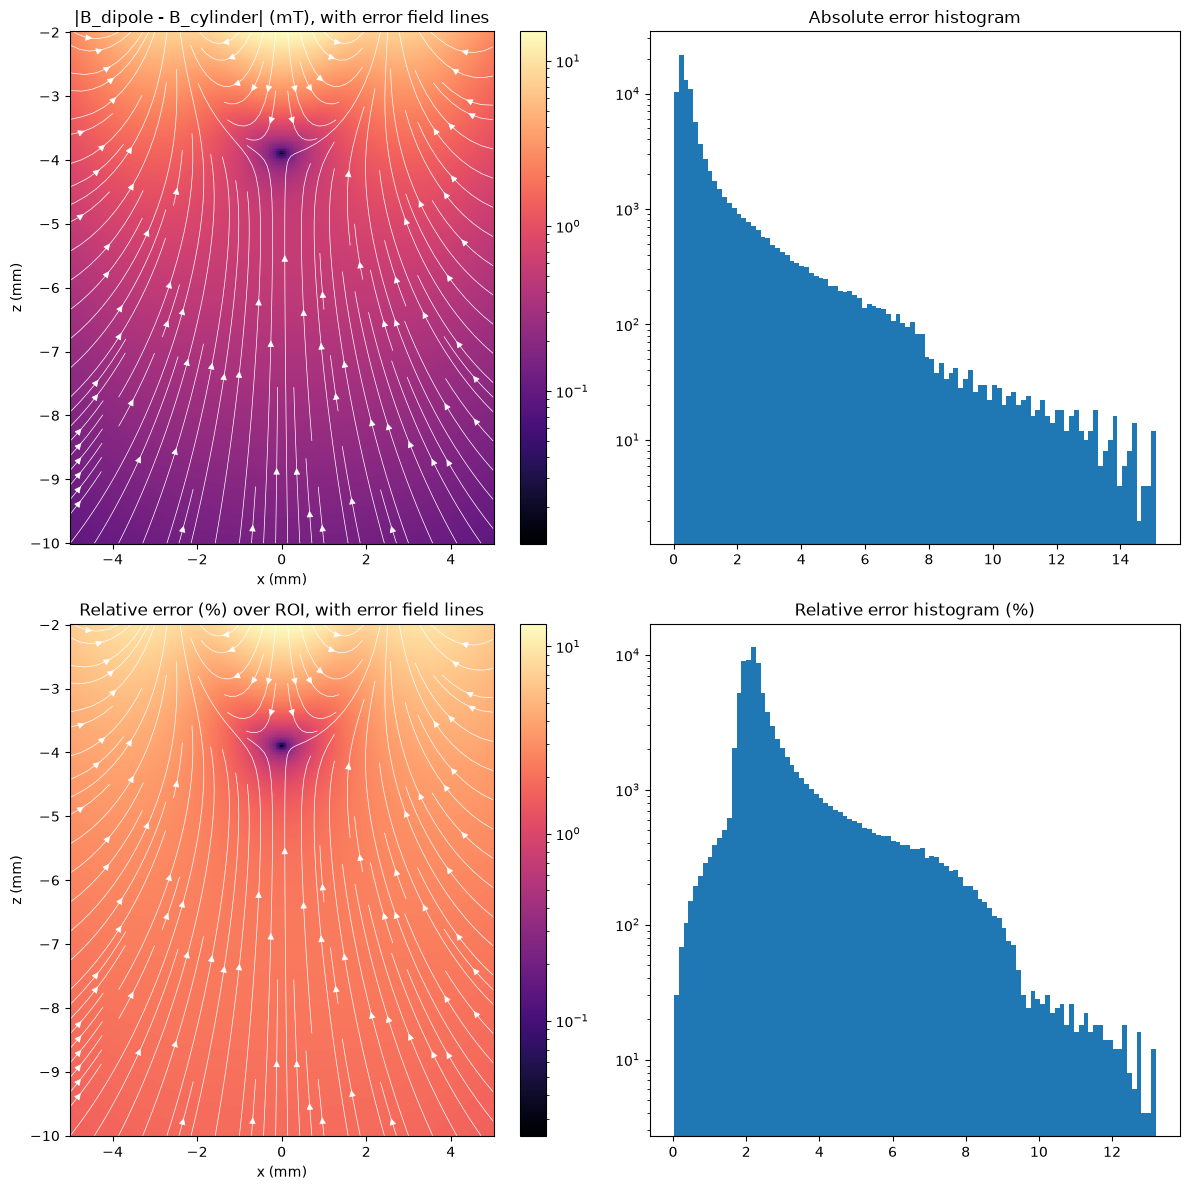

In [9]:
err_x, err_z = dip_err[..., 0], dip_err[..., 2]   # direction of the dipole-minus-cylinder discrepancy

fig, ax = plt.subplots(2, 2, figsize=(12, 12))

pcm = ax[0, 0].pcolormesh(Xc, Zc, dip_err_mag, shading="auto", cmap="magma",
                           norm=plt.matplotlib.colors.LogNorm(vmin=max(dip_err_mag.min(), 1e-3), vmax=dip_err_mag.max()))
ax[0, 0].streamplot(Xc, Zc, err_x, err_z, color='white', density=1.2, linewidth=0.5, arrowsize=1.0)
ax[0, 0].set_title("|B_dipole - B_cylinder| (mT), with error field lines")
ax[0, 0].set_xlabel("x (mm)"); ax[0, 0].set_ylabel("z (mm)")
fig.colorbar(pcm, ax=ax[0, 0])

ax[0, 1].hist(dip_err_mag.ravel(), bins=100, log=True)
ax[0, 1].set_title("Absolute error histogram")

pcm = ax[1, 0].pcolormesh(Xc, Zc, dip_err_rel, shading="auto", cmap="magma",
                           norm=plt.matplotlib.colors.LogNorm(vmin=max(dip_err_rel.min(), 1e-2), vmax=dip_err_rel.max()))
ax[1, 0].streamplot(Xc, Zc, err_x, err_z, color='white', density=1.2, linewidth=0.5, arrowsize=1.0)
ax[1, 0].set_title("Relative error (%) over ROI, with error field lines")
ax[1, 0].set_xlabel("x (mm)"); ax[1, 0].set_ylabel("z (mm)")
fig.colorbar(pcm, ax=ax[1, 0])

ax[1, 1].hist(dip_err_rel.ravel(), bins=100, log=True)
ax[1, 1].set_title("Relative error histogram (%)")

fig.tight_layout()
plt.show()


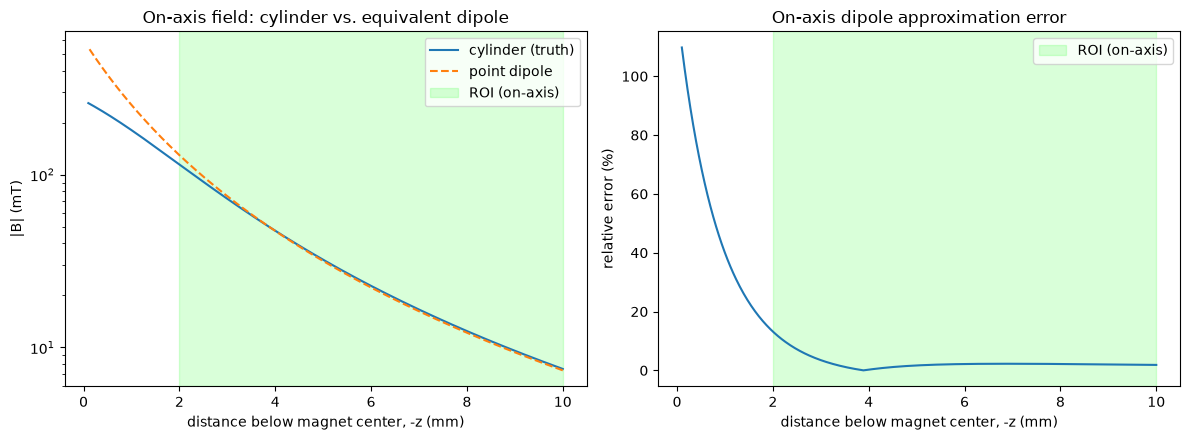

In [10]:
# On-axis (r=0) comparison, and where the dipole approximation converges to truth
z_axis = np.linspace(Z_BOT, -0.1, 500)
pts_axis = np.stack([np.zeros_like(z_axis), np.zeros_like(z_axis), z_axis], axis=-1)
B_cyl_axis = np.linalg.norm(magnet.getB(pts_axis), axis=-1)
B_dip_axis = np.linalg.norm(dipole.getB(pts_axis), axis=-1)
axis_err_rel = 100 * np.abs(B_dip_axis - B_cyl_axis) / B_cyl_axis

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].plot(-z_axis, B_cyl_axis, label="cylinder (truth)")
ax[0].plot(-z_axis, B_dip_axis, label="point dipole", linestyle="--")
ax[0].axvspan(-Z_TOP, -Z_BOT, color="lime", alpha=0.15, label="ROI (on-axis)")
ax[0].set_xlabel("distance below magnet center, -z (mm)")
ax[0].set_ylabel("|B| (mT)")
ax[0].set_yscale("log")
ax[0].legend()
ax[0].set_title("On-axis field: cylinder vs. equivalent dipole")

ax[1].plot(-z_axis, axis_err_rel)
ax[1].axvspan(-Z_TOP, -Z_BOT, color="lime", alpha=0.15, label="ROI (on-axis)")
ax[1].set_xlabel("distance below magnet center, -z (mm)")
ax[1].set_ylabel("relative error (%)")
ax[1].set_title("On-axis dipole approximation error")
ax[1].legend()

fig.tight_layout()
plt.show()


In [11]:
nx_interp, nz_interp = 51, 91
x_interp_line = np.linspace(0, 10, nx_interp)
z_interp_line = np.linspace(-20, -0.5, nz_interp)   # small margin above to show the magnet & cropped-out layer
Xs_interp, Zs_interp = np.meshgrid(x_interp_line, z_interp_line, indexing='ij')
pts = np.stack([Xs_interp.ravel(), np.zeros_like(Xs_interp.ravel()), Zs_interp.ravel()], axis=-1)

B_for_pts = magnet.getB(pts).reshape(nx_interp, nz_interp, 3)

B_interpolator = scipy.interpolate.RegularGridInterpolator((x_interp_line, z_interp_line), B_for_pts, method='cubic', bounds_error=True)


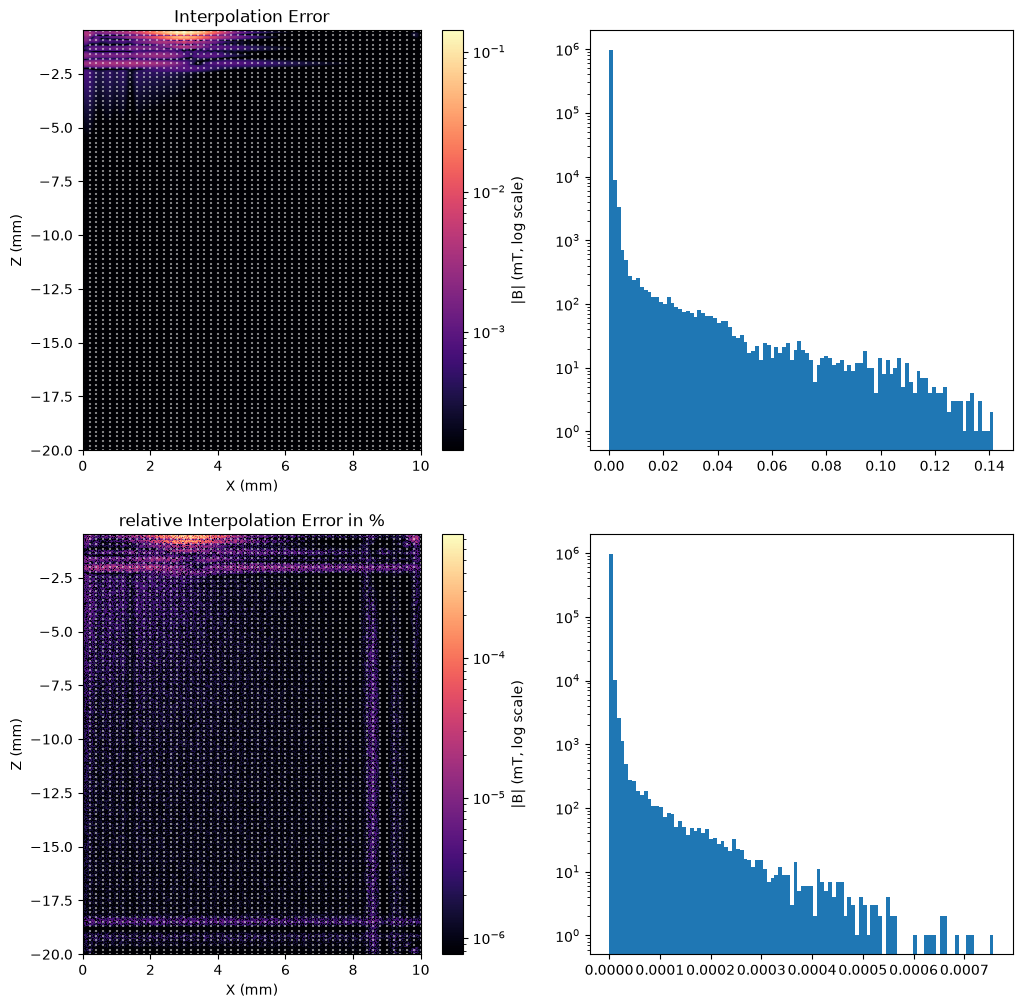

In [12]:
test_x_line = np.linspace(x_interp_line[0], x_interp_line[-1], 1000)
test_z_line = np.linspace(z_interp_line[0], z_interp_line[-1], 1000)    
test_X, test_Y = np.meshgrid(test_x_line, test_z_line, indexing='ij')

B_interp = B_interpolator((test_X, test_Y)).reshape(1000, 1000, 3)
B_truth  = magnet.getB(np.stack([test_X.ravel(), np.zeros_like(test_X.ravel()), test_Y.ravel()], axis=-1)).reshape(1000, 1000, 3)

interp_error = B_interp - B_truth
error_mag = np.linalg.norm(interp_error, axis=-1)

interp_error_rel = 100 % np.divide(np.linalg.norm(interp_error, axis=-1), np.linalg.norm(B_truth, axis=-1), out=np.zeros_like(error_mag), where=np.linalg.norm(B_truth, axis=-1)!=0)



fig, ax = plt.subplots(2, 2, figsize=(12, 12))
pcm = ax[0, 0].pcolormesh(test_X, test_Y, error_mag, shading="auto", cmap="magma",
                        norm=plt.matplotlib.colors.LogNorm(vmin=error_mag.min() + 0.001 * error_mag.max(), vmax=error_mag.max()))
ax[0, 0].scatter(Xs_interp, Zs_interp, s=1, color='white', marker='+', alpha=0.5)
ax[0, 0].set_title("Interpolation Error")
ax[0, 0].set_xlabel("X (mm)")
ax[0, 0].set_ylabel("Z (mm)")
ax[0, 1].hist(error_mag.ravel(), bins=100, log=True)
fig.colorbar(pcm, label="|B| (mT, log scale)")

pcm = ax[1, 0].pcolormesh(test_X, test_Y, interp_error_rel, shading="auto", cmap="magma",
                          norm=plt.matplotlib.colors.LogNorm(vmin=interp_error_rel.min() + 0.001 * interp_error_rel.max(), vmax=interp_error_rel.max()))
ax[1, 0].scatter(Xs_interp, Zs_interp, s=1, color='white', marker='+', alpha=0.5)
ax[1, 0].set_title("relative Interpolation Error in %")
ax[1, 0].set_xlabel("X (mm)")
ax[1, 0].set_ylabel("Z (mm)")
ax[1, 1].hist(interp_error_rel.ravel(), bins=100, log=True)

fig.colorbar(pcm, label="|B| (mT, log scale)")

plt.show()

In [ ]:
def hex_array_2d(arr):
    lines = []
    for row in arr:
        point_strings = []
        for point in row:
            point_string = f"Vec2( {point[0].hex()}f, {point[1].hex()}f )"
            point_strings.append(point_string)
        row_string = ", ".join(point_strings)
        lines.append("{" + row_string + "}")
    return "{\n" + ",\n".join(lines) + "\n}"

field_2d = B_for_pts.swapaxes(0, 1)[:, :, (0, 2)]
arr = hex_array_2d(field_2d)

HEADER_FILENAME = "magnet_model/magnet_model_table.h"
HEADER_PATH = "../firmware/include/" + HEADER_FILENAME
CPP_PATH = "../firmware/src/magnet_model/magnet_model_table.cpp"

GENERATED_BANNER = """// ============================================================================
// AUTO-GENERATED -- DO NOT EDIT BY HAND.
// Written directly by cell af552cc7 of magnet_field_model/field_approximation.ipynb.
// Re-running that cell overwrites this file; manual edits here will be lost.
// ============================================================================
"""

header = f"""{GENERATED_BANNER}
#pragma once
#include "math3D.h"

struct Point {{ float r; float z; }};

using Vec2 = Eigen::Vector2f;
constexpr int NR = {nx_interp};
constexpr int NZ = {nz_interp};

constexpr Point BICUBIC_ORIGIN = {{ {x_interp_line[0] }, {z_interp_line[0] } }};
constexpr Point BICUBIC_FAR    = {{ {x_interp_line[-1]}, {z_interp_line[-1]} }};

extern const Vec2 BICUBIC_INTERPOLATION_TABLE[NZ][NR];

""" 

cpp_file = f"""{GENERATED_BANNER}
#include "{HEADER_FILENAME}"

const Vec2 BICUBIC_INTERPOLATION_TABLE[NZ][NR] = {arr};
"""

with open(HEADER_PATH, mode="w") as file:
    file.write(header)
with open(CPP_PATH, mode="w") as file:
    file.write(cpp_file)

# print(constructor)


In [14]:
print(header)

print(cpp_file)


#pragma once
#include "BicubicField.h"

struct Point { float r; float z; };

using Vec2 = Eigen::Vector2f;
constexpr int NR = { 51 };
constexpr int NZ = { 91 };

constexpr Point BICUBIC_ORIGIN = { 0.0, -20.0 };
constexpr Point BICUBIC_FAR    = { 10.0, -0.5 };

extern const Vec2 BICUBIC_INTERPOLATION_TABLE[NZ][NR];



#include "magnet_model/magnet_model_table.h"

const Vec2 BICUBIC_INTERPOLATION_TABLE[NZ][NR] = {
{Vec2( 0x0.0p+0f, -0x1.577e8f55beb0ep+0f ), Vec2( 0x1.200261987f352p-6f, -0x1.576a6b3fcf44ep+0f ), Vec2( 0x1.1fd823740d709p-5f, -0x1.572e07db4d9acp+0f ), Vec2( 0x1.af5ab6b6ed968p-5f, -0x1.56c97fb80b1bap+0f ), Vec2( 0x1.1f2f817c73ed9p-4f, -0x1.563cff00347dfp+0f ), Vec2( 0x1.665dbb5e43b7bp-4f, -0x1.5588c35031efap+0f ), Vec2( 0x1.ad237959d7985p-4f, -0x1.54ad1b7ed358ep+0f ), Vec2( 0x1.f36c72a2b56f2p-4f, -0x1.53aa6756177e0p+0f ), Vec2( 0x1.1c925959fbb71p-3f, -0x1.5281173cffedbp+0f ), Vec2( 0x1.3f1c532bceae0p-3f, -0x1.5131abd2eefe0p+0f ), Vec2( 0x1.614a941c93f03p-3f, -0x1.4fbcb57d27